# Informal results script for experimental results mid-development

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
%%javascript
IPython.notebook.kernel.execute('nb_name = "' + IPython.notebook.notebook_name + '"')

import os
import sys

sys.path.append(os.path.join(os.path.dirname(nb_name), '..'))

<IPython.core.display.Javascript object>

In [2]:
from plotting_functions import create_pearsons_violin

# Pre-modification results to identify gene subset to target

In [81]:
DATA_ROOT = '../data'
results = pd.read_csv(f'{DATA_ROOT}/Pearsons_results_ACC.csv', index_col = 0, header = 0)
results['pearsons'] = 1 - results['train_loss']

In [82]:
negative_correlations = results[results['train_loss'] > 1]
negative_correlations['train_pearsons'] = 1 - negative_correlations['train_loss']
negative_correlations['test_pearsons'] = 1 - negative_correlations['test_loss']

In [83]:
negative_correlations_to_plot = negative_correlations[['train_pearsons', 'test_pearsons']]
negative_correlations_to_plot.columns = ['Train', 'Test']
negative_correlations_to_plot = negative_correlations_to_plot.melt()
negative_correlations_to_plot.columns = ['dataset', 'pearsons']
negative_correlations_to_plot.dataset.value_counts()

dataset
Train    894
Test     894
Name: count, dtype: int64

In [84]:
negative_correlations[['train_pearsons', 'test_pearsons']]['test_pearsons'].describe()

count    894.000000
mean      -0.225522
std        0.197513
min       -0.850348
25%       -0.320117
50%       -0.173309
75%       -0.070931
max        0.056655
Name: test_pearsons, dtype: float64

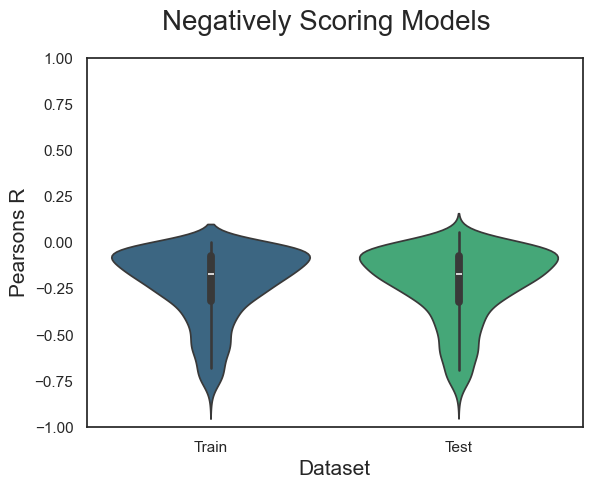

In [86]:
create_pearsons_violin(negative_correlations_to_plot, y_col = 'pearsons', title = 'Negatively Scoring Models', figure_root = './figures/experimental_figures/', file_title = 'negative_scoring_violins')

# Post-modification results to asssess change impacts

In [3]:
exp_results = pd.read_csv('../model_building/data/EXPERIMENTAL_results.csv', index_col = 0)

In [4]:
exp_results['train_pearsons'] = 1 - exp_results['train_loss']
exp_results['test_pearsons'] = 1 - exp_results['test_loss']

In [5]:
exp_results

,train_loss,test_loss,stopped_early,in_features,train_pearsons,test_pearsons
AARD,0.577791,0.618469,1.0,13,0.422209,0.381531
ABCA12,0.565800,0.569968,1.0,22,0.434200,0.430032
ABCA13,1.190854,1.156047,1.0,4,-0.190854,-0.156047
ABRA,1.062784,1.075646,1.0,2,-0.062784,-0.075646
ACMSD,0.406339,0.400415,1.0,2,0.593661,0.599585
...,...,...,...,...,...,...
ZNHIT3,1.057506,1.029482,1.0,2,-0.057506,-0.029482
ZNHIT6,0.542348,0.556630,1.0,8,0.457652,0.443370
ZPBP,1.069619,1.081927,1.0,11,-0.069619,-0.081927
ZSWIM2,0.668094,0.661828,1.0,30,0.331906,0.338172


In [6]:
exp_results[exp_results['train_pearsons'] > 0]

,train_loss,test_loss,stopped_early,in_features,train_pearsons,test_pearsons
AARD,0.577791,0.618469,1.0,13,0.422209,0.381531
ABCA12,0.565800,0.569968,1.0,22,0.434200,0.430032
ACMSD,0.406339,0.400415,1.0,2,0.593661,0.599585
ACO1,0.241371,0.247715,1.0,68,0.758629,0.752285
ACOT4,0.963211,0.958882,1.0,1,0.036789,0.041118
...,...,...,...,...,...,...
ZNF705A,0.945318,0.914341,1.0,5,0.054682,0.085659
ZNF728,0.548792,0.520824,1.0,34,0.451208,0.479176
ZNHIT6,0.542348,0.556630,1.0,8,0.457652,0.443370
ZSWIM2,0.668094,0.661828,1.0,30,0.331906,0.338172


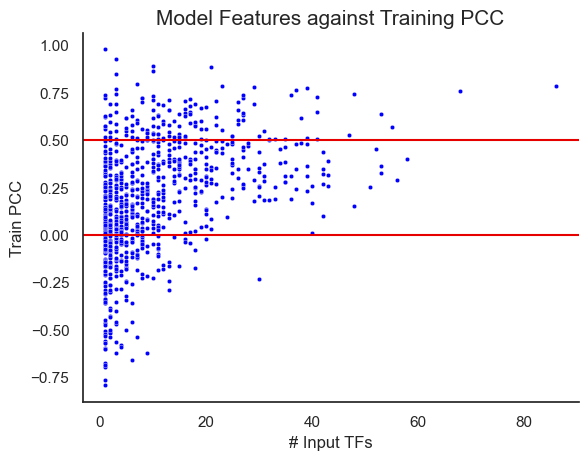

In [7]:
sns.set_theme(style = 'white')

sns.scatterplot(exp_results, y='train_pearsons', x = 'in_features', s = 10, color = '#0000ff', legend = False)
plt.ylabel('Train PCC')
plt.xlabel('# Input TFs')
plt.title('Model Features against Training PCC', fontsize = 15)
sns.despine()
plt.axhline(0.5, color = '#e60000')
plt.axhline(0.0, color = '#e60000')
plt.savefig('Experimental_feature_number_vs_trainingPCC', dpi = 300)


In [16]:
exp_results

,train_loss,test_loss,stopped_early,in_features,train_pearsons,test_pearsons
AARD,0.577791,0.618469,1.0,13,0.422209,0.381531
ABCA12,0.565800,0.569968,1.0,22,0.434200,0.430032
ABCA13,1.190854,1.156047,1.0,4,-0.190854,-0.156047
ABRA,1.062784,1.075646,1.0,2,-0.062784,-0.075646
ACMSD,0.406339,0.400415,1.0,2,0.593661,0.599585
...,...,...,...,...,...,...
ZNHIT3,1.057506,1.029482,1.0,2,-0.057506,-0.029482
ZNHIT6,0.542348,0.556630,1.0,8,0.457652,0.443370
ZPBP,1.069619,1.081927,1.0,11,-0.069619,-0.081927
ZSWIM2,0.668094,0.661828,1.0,30,0.331906,0.338172


In [49]:
exp_results[exp_results['in_features'] >30]

,train_loss,test_loss,stopped_early,in_features,train_pearsons,test_pearsons
ACO1,0.241371,0.247715,1.0,68,0.758629,0.752285
ACRBP,0.430867,0.421958,1.0,55,0.569133,0.578042
ARMCX2,0.501297,0.501482,1.0,32,0.498703,0.498518
BEX1,0.742421,0.772032,1.0,43,0.257579,0.227968
C14orf39,0.734518,0.768173,1.0,42,0.265482,0.231827
...,...,...,...,...,...,...
TMEM61,0.688986,0.730409,1.0,35,0.311014,0.269591
TRIM63,0.756481,0.768837,1.0,37,0.243519,0.231163
VAMP7,0.539028,0.527240,1.0,35,0.460972,0.472760
XKR3,0.691610,0.667110,1.0,31,0.308390,0.332890


In [48]:
exp_results[exp_results['in_features'] >30]['stopped_early'].value_counts()

stopped_early
1.0    61
Name: count, dtype: int64

In [50]:
#transfrom dataframe to work with create_pearsons_violin
to_plot_df = exp_results[exp_results['stopped_early'] == True][['train_pearsons', 'test_pearsons']]
to_plot_df.columns = ['Train', 'Test']
to_plot_df = to_plot_df.melt()
to_plot_df.columns = ['dataset', 'pearsons']

In [51]:
to_plot_df[to_plot_df['dataset'] == 'Train'].describe()

,pearsons
count,877.000000
mean,0.177616
std,0.303315
min,-0.794325
25%,-0.015237
50%,0.184911
75%,0.389232
max,0.977678


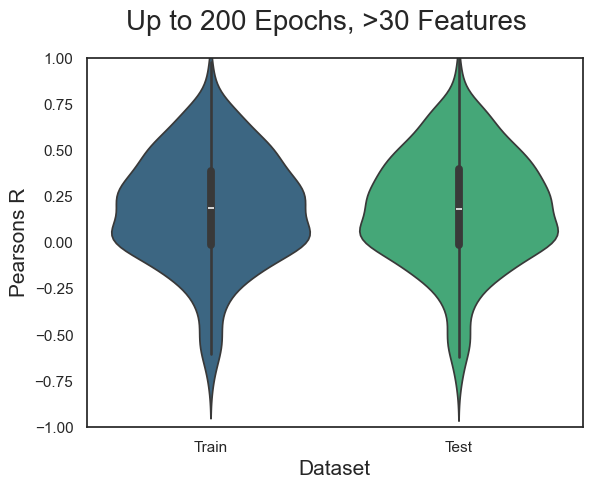

In [52]:
create_pearsons_violin(to_plot_df, y_col = 'pearsons', title = 'Up to 200 Epochs, >30 Features', figure_root = './figures/experimental_figures/', file_title = 'DELETE_ME', ylim = (-1, 1))

In [10]:
exp_results['train_pearsons'].describe()

count    893.000000
mean       0.182261
std        0.302886
min       -0.794325
25%       -0.006319
50%        0.189064
75%        0.391615
max        0.977678
Name: train_pearsons, dtype: float64